In [1]:
import pandas, numpy, scipy

In [2]:
import sklearn, sklearn.preprocessing, sklearn.decomposition

In [3]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

# 0. user-defined variables

In [4]:
input_file = '/Users/adrian/research/bmcbf/019_fossvogur/002_quantification/DESeq2_TPM_values.tsv'

# 1. read expression

In [5]:
expression = pandas.read_csv(input_file, sep='\t', index_col=0)
print(expression.shape)
expression

(39546, 31)


,501-KO13_VHN-10,501-KO13_VHN-2,501-KO13_VHN-6,C1_RD-10,C1_RD-4,C1-RD-16,C3_RD-1,C3_RD-13,C3_RD-7,KO13_VHN-11,...,siMITF_1,siMITF_2,siMITF_3,SkMel28-MITFKO_ev_skmel28_rep1,SkMel28-MITFKO_ev_skmel28_rep2,SkMel28-MITFKO_ev_skmel28_rep3,SkMel28-MITFKO_ev_skmel28_rep4,SkMel28-MITFKO_mitf_x6_rep1,SkMel28-MITFKO_mitf_x6_rep3,SkMel28-MITFKO_mitf_x6_rep4
ENSG00000000003,19.954768,16.072870,17.216985,12.573916,14.588913,12.295120,9.417557,10.615236,9.792345,8.192698,...,13.011276,13.035136,12.300864,9.097209,9.806654,12.244351,12.179835,17.984601,12.499056,10.895395
ENSG00000000005,0.000000,0.000000,0.000000,0.006439,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000419,213.351825,154.868847,171.142164,151.675645,150.963551,161.266526,162.231758,208.519333,180.542746,176.757310,...,140.969606,163.263264,140.126440,152.065078,146.963798,159.427516,180.241348,197.693333,144.099788,136.583522
ENSG00000000457,6.972656,5.472320,5.674427,5.102438,5.701764,5.124692,3.753332,3.658351,4.357829,4.365342,...,4.957449,7.639253,7.143860,4.644776,3.992320,6.102643,3.590144,5.672788,4.962348,4.242799
ENSG00000000460,34.320934,30.989133,31.857731,34.709662,40.242893,39.121552,20.248742,19.796544,17.666131,20.489020,...,35.446273,26.404204,29.517458,20.780175,22.200583,30.912937,20.707054,26.297054,17.887952,14.196562
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000291297,5.551173,8.142017,5.234141,5.888645,4.128012,4.422236,3.628851,2.938763,4.105825,1.935839,...,3.921978,3.808555,3.876395,5.742134,5.220425,6.054220,5.305273,2.120733,2.756115,2.122733
ENSG00000291298,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.096603,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.944026
ENSG00000291299,1.063779,2.764225,1.930863,2.019971,1.195522,1.503419,1.505173,1.120233,1.228891,1.033138,...,1.427956,1.790859,2.806258,1.784678,1.767580,1.662962,2.593021,0.870331,2.213504,1.361509
ENSG00000291300,0.000000,0.000000,0.000000,0.000000,0.028758,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [6]:
columns = [
    "siCTRL_1", "siCTRL_2", "siCTRL_3",
    "KO24_VHN-1", "KO24_VHN-5", "KO24_VHN-9",
    "KO13_VHN-11", "KO13_VHN-3", "KO13_VHN-7",
    "C3_RD-1", "C3_RD-13", "C3_RD-7",
]

expression = expression[columns]

In [7]:
for element in expression.columns:
    print(element)

siCTRL_1
siCTRL_2
siCTRL_3
KO24_VHN-1
KO24_VHN-5
KO24_VHN-9
KO13_VHN-11
KO13_VHN-3
KO13_VHN-7
C3_RD-1
C3_RD-13
C3_RD-7


# 3. filter and transform

In [8]:
substantial_expression = expression[expression.max(axis=1) >= 2]
high_expression = expression[expression.max(axis=1) >= 100]

print(substantial_expression.shape)
print(high_expression.shape)

(13883, 12)
(2414, 12)


In [9]:
transpose = substantial_expression.transpose()
pca_substantial_expression = numpy.log2(transpose + 1)

transpose = high_expression.transpose()
pca_high_expression = numpy.log2(transpose + 1)

# 4. visualize substantial expression

In [10]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_substantial_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.54306316 0.17904126]


In [11]:
#my_colors = ['gold']*3 + ['skyblue']*3 + ['tab:red']*3 + ['black']*3 + ['tab:green']*3
#my_markers = ['o']*9 + ['s']*6

#legend_elements = [
    
#    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='gold', markeredgecolor='white', markersize=20, alpha=2/3),
#    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='skyblue', markeredgecolor='white', markersize=20, alpha=2/3),
#    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='tab:red', markeredgecolor='white', markersize=20, alpha=2/3),
#    matplotlib.lines.Line2D([0], [0], color='white', marker='s', markerfacecolor='black', markeredgecolor='white', markersize=20, alpha=2/3),
#    matplotlib.lines.Line2D([0], [0], color='white', marker='s', markerfacecolor='tab:green', markeredgecolor='white', markersize=20, alpha=2/3)
#    
#]

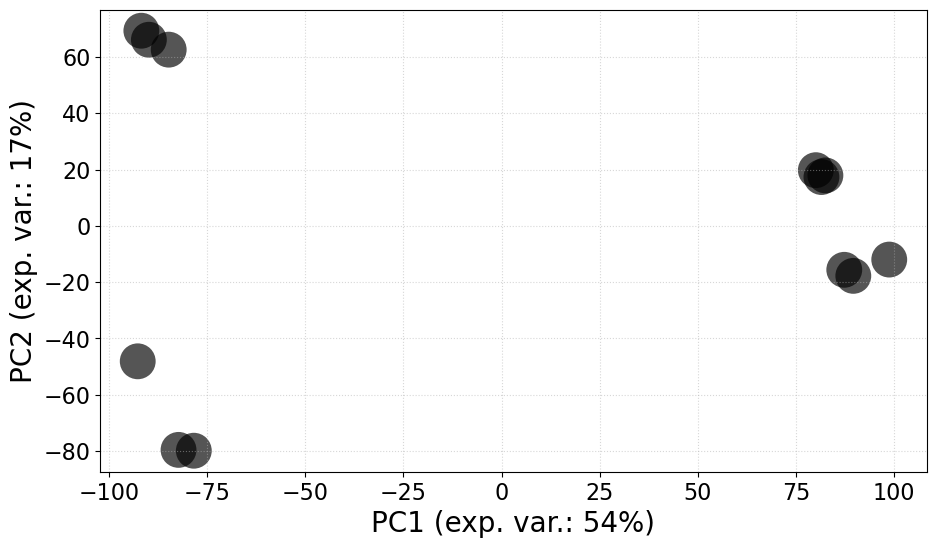

In [12]:
for i in range(len(new)):
    #matplotlib.pyplot.scatter(new[i,0], new[i,1], s=666, c=my_colors[i], marker=my_markers[i], alpha=2/3, edgecolors='none')
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=666, c='black', marker='o', alpha=2/3, edgecolors='none')

#matplotlib.pyplot.legend(legend_elements, ['h1', 'h2 low', 'h2 high', 'KO', 'WT'], ncol=2, loc='upper left', bbox_to_anchor=(1.05, 1))
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(alpha=0.5, ls=':')

matplotlib.pyplot.show()
#matplotlib.pyplot.savefig('pca.svg')

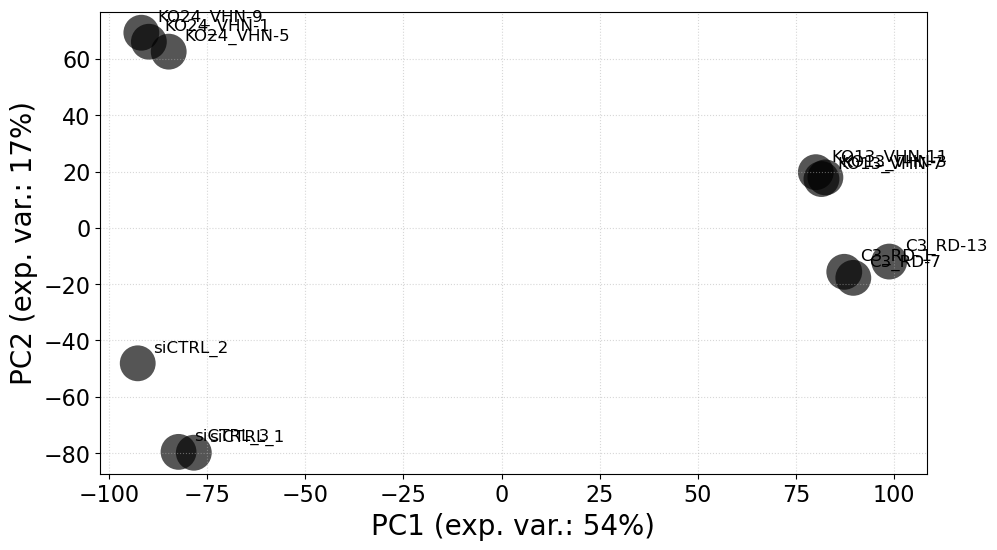

In [13]:
for i in range(len(new)):
    #matplotlib.pyplot.scatter(new[i,0], new[i,1], s=666, c=my_colors[i], marker=my_markers[i], alpha=2/3, edgecolors='none')
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=666, c='black', marker='o', alpha=2/3, edgecolors='none')

    epsilon = 4
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, expression.columns[i], size=12)

#matplotlib.pyplot.legend(legend_elements, ['h1', 'h2 low', 'h2 high', 'KO', 'WT'], ncol=2, loc='upper left', bbox_to_anchor=(1.05, 1))
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(alpha=0.5, ls=':')

# 4. visualize high expression

In [14]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_high_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.56326214 0.17965081]


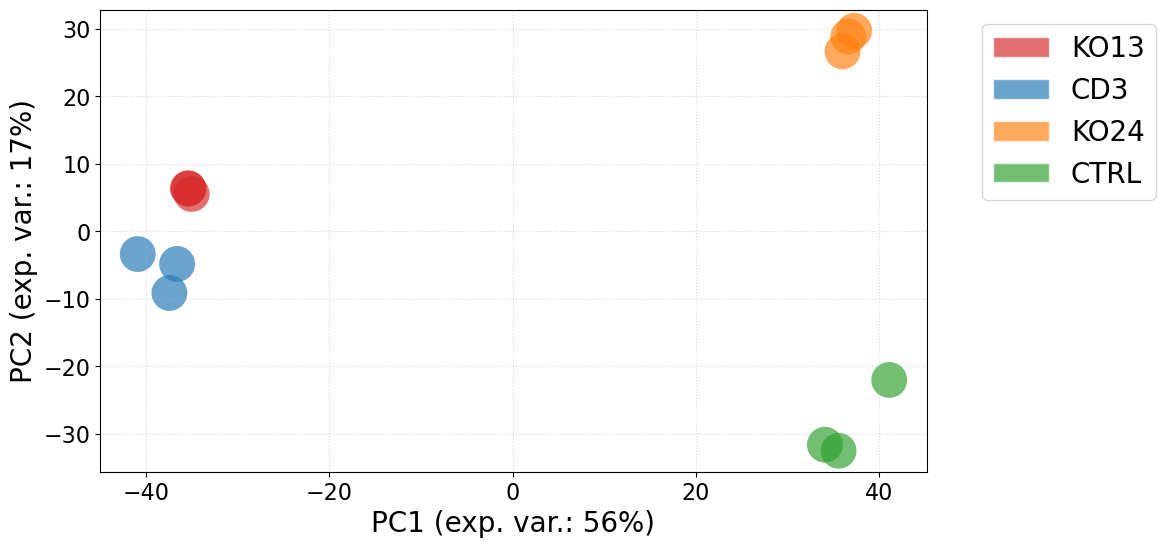

In [15]:
for i in range(len(new)):

    name = pca_high_expression.index[i]
    
    # colors
    if 'KO13' in name:
        the_color = 'tab:red'
    elif 'C3' in name:
        the_color = 'tab:blue'
    elif 'KO24' in name:
        the_color = 'tab:orange'
    elif 'CTRL' in name:
        the_color = 'tab:green'
    else:
        print('error')
        
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=666, c=the_color, marker='o', alpha=2/3, edgecolors='none')
    #matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, expression.columns[i], size=12)


    legend_elements = [
        matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:red',      edgecolor='white', alpha=2/3),
        matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:blue',    edgecolor='white', alpha=2/3),
        matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:orange',    edgecolor='white', alpha=2/3),
        matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:green',    edgecolor='white', alpha=2/3)
    ]    
    matplotlib.pyplot.legend(legend_elements, ['KO13', 'CD3', 'KO24', 'CTRL'], 
                             ncol=1, loc='upper left', bbox_to_anchor=(1.05, 1))
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(alpha=0.5, ls=':')
matplotlib.pyplot.show()

### distributions

In [16]:
log2_tpm_PO = numpy.log2(expression + 1)
log2_tpm_PO.head()

,siCTRL_1,siCTRL_2,siCTRL_3,KO24_VHN-1,KO24_VHN-5,KO24_VHN-9,KO13_VHN-11,KO13_VHN-3,KO13_VHN-7,C3_RD-1,C3_RD-13,C3_RD-7
ENSG00000000003,3.642808,3.893687,3.735644,3.906852,3.981642,3.966227,3.200488,3.303112,3.408116,3.380945,3.537947,3.431936
ENSG00000000005,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000419,7.077194,7.478815,6.966033,7.388181,7.477415,7.327404,7.473765,7.511084,7.481949,7.350778,7.710940,7.504165
ENSG00000000457,2.565613,3.086905,2.680043,3.136540,3.131629,3.078493,2.423670,2.359342,2.444644,2.248939,2.219819,2.421649
ENSG00000000460,5.136039,5.097776,5.127133,4.827228,5.018969,4.674653,4.425528,4.497089,4.427683,4.409306,4.378272,4.222351


143
14.207689816849594


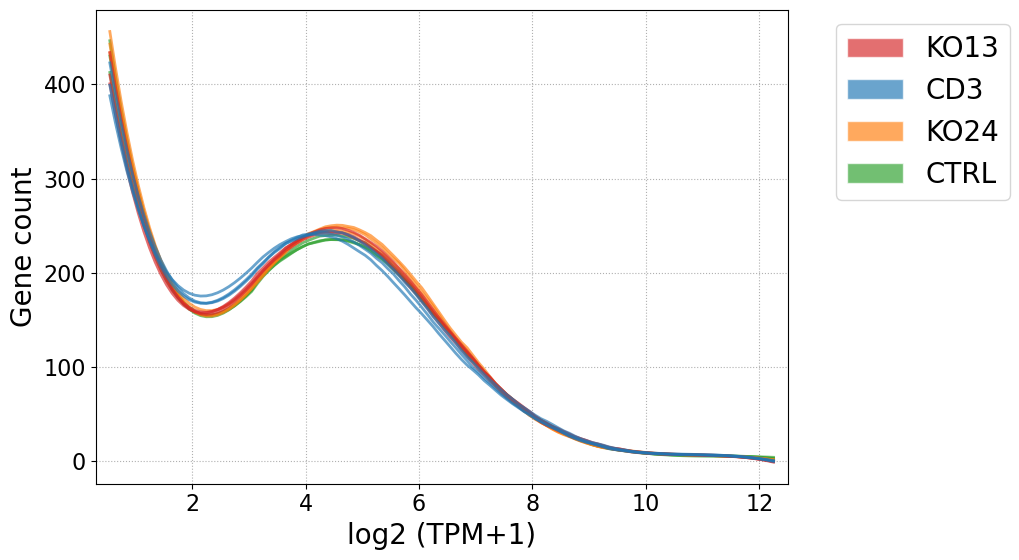

In [17]:
found_max = 14.3
number_of_bins = int(found_max*10)
print(number_of_bins)

absolute_max = 0
working_samples = log2_tpm_PO.columns.to_list()

for i in range(len(working_samples)):

    name = working_samples[i]

    # colors
    if 'KO13' in name:
        the_color = 'tab:red'
    elif 'C3' in name:
        the_color = 'tab:blue'
    elif 'KO24' in name:
        the_color = 'tab:orange'
    elif 'CTRL' in name:
        the_color = 'tab:green'
   
    else:
        print('error')
        
    log2TPM = log2_tpm_PO.loc[:, name]
    if max(log2TPM) > absolute_max:
        absolute_max = max(log2TPM)
                
    hist, bin_edges = numpy.histogram(log2TPM, bins=number_of_bins, range=(0, found_max))
    half_bin = (bin_edges[1] - bin_edges[0])/2
    x = bin_edges + half_bin
    x = x[:-1]
  
    plotting_x = x[5:-20]
    plotting_hist = hist[5:-20]
    
    #matplotlib.pyplot.plot(plotting_x, plotting_hist, 'o', alpha=1/5, mec='none', color=the_color)
    yhat = scipy.signal.savgol_filter(plotting_hist, 51, 3)

    matplotlib.pyplot.plot(plotting_x, yhat, '-', lw=2, alpha=2/3, color=the_color)
    
matplotlib.pyplot.xlim([numpy.min(plotting_x)-0.25, numpy.max(plotting_x)+0.25])

legend_elements = [
        matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:red',      edgecolor='white', alpha=2/3),
        matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:blue',    edgecolor='white', alpha=2/3),
        matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:orange',    edgecolor='white', alpha=2/3),
        matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:green',    edgecolor='white', alpha=2/3)
    ]    
matplotlib.pyplot.legend(legend_elements, ['KO13', 'CD3', 'KO24', 'CTRL'], 
                             ncol=1, loc='upper left', bbox_to_anchor=(1.05, 1))

matplotlib.pyplot.xlabel('log2 (TPM+1)')
matplotlib.pyplot.ylabel('Gene count')
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.tight_layout()

print(absolute_max)